In [1]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("health_data.csv")

df.head()


,Country,Year,Population,Life_Expectancy,Infant_Mortality,Health_Expenditure_Percent,GDP_Per_Capita
0,Sri Lanka,2019,21413250,76.9,7.1,3.8,4080
1,Sri Lanka,2020,21414900,77.1,6.8,4.1,3850
2,Sri Lanka,2021,21497000,76.4,7.2,4.5,4010
3,Sri Lanka,2022,21592000,76.8,6.9,4.8,3350
4,Sri Lanka,2023,21789000,77.2,6.5,5.0,3620


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nCountries:")
print(df["Country"].unique())

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistics:")
print(df.describe())

Rows: 25
Columns: 7

Countries:
['Sri Lanka' 'India' 'Japan' 'USA' 'Germany']

Missing values:
Country                       0
Year                          0
Population                    0
Life_Expectancy               0
Infant_Mortality              0
Health_Expenditure_Percent    0
GDP_Per_Capita                0
dtype: int64

Statistics:
              Year    Population  Life_Expectancy  Infant_Mortality  \
count    25.000000  2.500000e+01        25.000000         25.000000   
mean   2021.000000  3.915586e+08        77.768000          9.256000   
std       1.443376  5.231939e+08         5.497706         10.403448   
min    2019.000000  2.141325e+07        67.200000          1.500000   
25%    2020.000000  8.316087e+07        76.400000          3.000000   
50%    2021.000000  1.256816e+08        77.500000          5.300000   
75%    2022.000000  3.332876e+08        81.100000          7.100000   
max    2023.000000  1.428628e+09        84.900000         32.000000   

       Health_E

In [5]:
df["Health_Expenditure"] = (
    df["GDP_Per_Capita"] *
    df["Health_Expenditure_Percent"] / 100
)

df.head()

,Country,Year,Population,Life_Expectancy,Infant_Mortality,Health_Expenditure_Percent,GDP_Per_Capita,Health_Expenditure
0,Sri Lanka,2019,21413250,76.9,7.1,3.8,4080,155.04
1,Sri Lanka,2020,21414900,77.1,6.8,4.1,3850,157.85
2,Sri Lanka,2021,21497000,76.4,7.2,4.5,4010,180.45
3,Sri Lanka,2022,21592000,76.8,6.9,4.8,3350,160.80
4,Sri Lanka,2023,21789000,77.2,6.5,5.0,3620,181.00


In [6]:
df["Health_Risk_Score"] = (
    df["Infant_Mortality"] / df["Life_Expectancy"]
)

df.head()

,Country,Year,Population,Life_Expectancy,Infant_Mortality,Health_Expenditure_Percent,GDP_Per_Capita,Health_Expenditure,Health_Risk_Score
0,Sri Lanka,2019,21413250,76.9,7.1,3.8,4080,155.04,0.092328
1,Sri Lanka,2020,21414900,77.1,6.8,4.1,3850,157.85,0.088197
2,Sri Lanka,2021,21497000,76.4,7.2,4.5,4010,180.45,0.094241
3,Sri Lanka,2022,21592000,76.8,6.9,4.8,3350,160.80,0.089844
4,Sri Lanka,2023,21789000,77.2,6.5,5.0,3620,181.00,0.084197


In [7]:
best = df.groupby("Country")["Life_Expectancy"].mean()

print(best.sort_values(ascending=False))

Country
Japan        84.68
Germany      81.08
USA          77.54
Sri Lanka    76.88
India        68.66
Name: Life_Expectancy, dtype: float64


In [8]:
print(best.sort_values(ascending=False).head(3))

Country
Japan      84.68
Germany    81.08
USA        77.54
Name: Life_Expectancy, dtype: float64


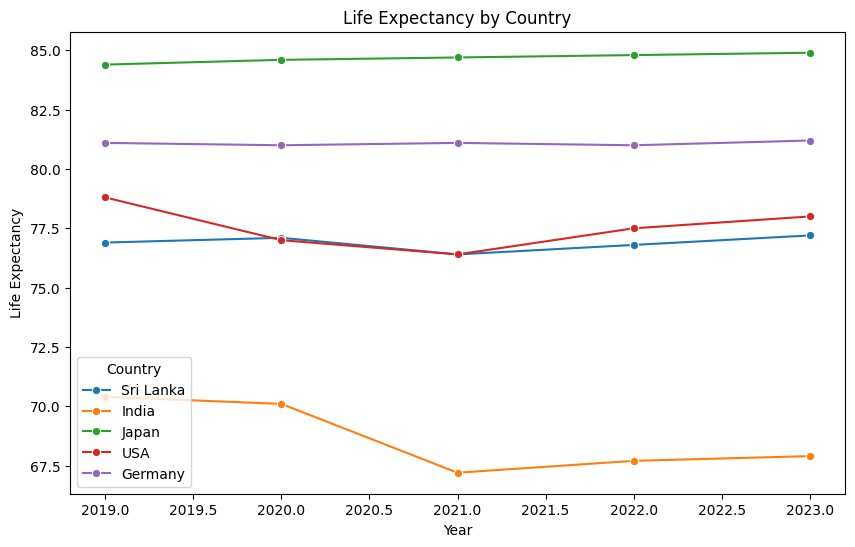

In [9]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df,
    x="Year",
    y="Life_Expectancy",
    hue="Country",
    marker="o"
)

plt.title("Life Expectancy by Country")
plt.ylabel("Life Expectancy")
plt.show()

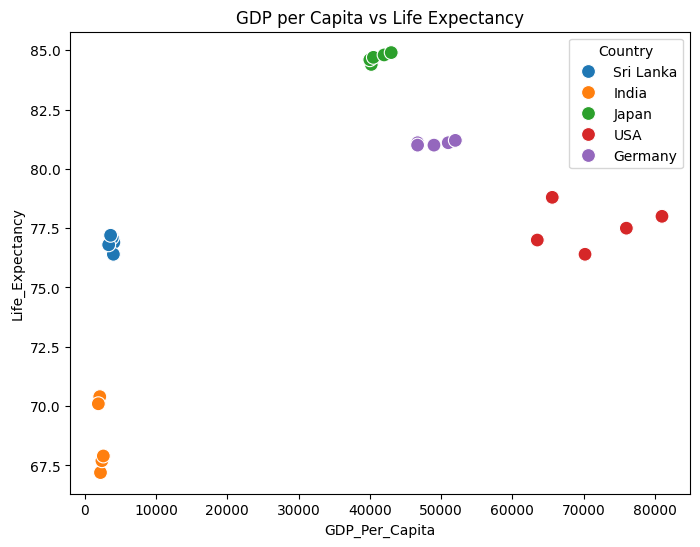

In [10]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="GDP_Per_Capita",
    y="Life_Expectancy",
    hue="Country",
    s=100
)

plt.title("GDP per Capita vs Life Expectancy")
plt.show()

In [11]:
correlation = df["GDP_Per_Capita"].corr(
    df["Life_Expectancy"]
)

print("Correlation:", correlation)

Correlation: 0.5610314432538961
